In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc


In [179]:
#1 - Calcular médias móveis de transações nos últimos 3, 6 e 12 meses por cliente
df = pd.read_csv('transacoes_clientes.csv')

In [180]:
#print(df.loc[df['id_cliente'] == 488])
#df_cliente_mes = df.loc[(df['id_cliente'] == 488) & (df['mes'].isin([3, 6, 12]))]
#print(df_cliente_mes)
#print("Média: " + str(df_cliente_mes['valor_total'].mean()))

filtro = df.loc[df['mes'].isin([3, 6, 12])]
print(filtro.groupby('id_cliente')[['valor_total']].mean().sort_values(by='id_cliente', ascending=True))

             valor_total
id_cliente              
1            4466.585000
2           15489.450000
3           15710.840000
4            7816.076667
5           11280.870000
...                  ...
496          8475.500000
497          6956.730000
498          9310.760000
499          3908.720000
500         13054.395000

[460 rows x 1 columns]


In [181]:
#2- Realizar merge entre bases de perfiç, transações e reclamações em um único dataframe
df_clientes = pd.read_csv('clientes.csv')
df_transacoes = pd.read_csv('transacoes_clientes.csv')
df_reclamacoes = pd.read_csv('reclamacoes.csv')

df_transacoes = df_transacoes.sort_values(['id_cliente', 'mes'], ascending=True)
#print(df_transacoes.head())

df_concatenado = pd.concat([df_clientes, df_transacoes, df_reclamacoes], axis=1, ignore_index=False)
print(df_concatenado.head())


   id_cliente  idade  tempo_relacionamento_meses  numero_produtos  \
0         1.0   31.0                       167.0              1.0   
1         2.0   57.0                       139.0              3.0   
2         3.0   19.0                       233.0              2.0   
3         4.0   33.0                       174.0              5.0   
4         5.0   56.0                       142.0              1.0   

        segmento  id_cliente  mes  quantidade_transacoes  valor_total  \
0  universitario         476    9                     45      6685.86   
1         varejo         279    9                     77        14.52   
2         varejo         402    9                     94      1532.50   
3  universitario         414   10                     18      7049.04   
4         varejo         423   11                     80     15181.30   

   id_cliente       motivo  resolvido  
0        25.0      tarifas        1.0  
1       458.0       outros        1.0  
2        60.0       outros

### Gere um gráfico de barras com a taxa de churn por tipo de produto (cartão, conta, investimento)


In [182]:
#3 - Gere um gráfico de barras com a taxa de churn por tipo de produto (cartão, conta, investimento)

#Criando a coluna tipo_produto 
tipos = ['cartao', 'conta', 'investimento']

df_clientes['tipo_produto'] = np.random.choice(tipos, size=500)

In [183]:
#Criando a coluna churn para o exemplo
# Definindo a probabilidade base
df_concatenado['probabilidade'] = 0.1  # Probabilidade inicial de 10%

# Regra: Reclamações não resolvidas aumentam o risco em 3x 
df_concatenado.loc[df_concatenado['resolvido'] == 0, 'probabilidade'] *= 3

# Regra: Baixa atividade (ex: menos de 20 transações) aumenta o risco 
df_concatenado.loc[df_concatenado['quantidade_transacoes'] < 20, 'probabilidade'] += 0.2

# Criando a coluna Churn binária (Target) baseada na probabilidade calculada
# Isso garante que o target seja entre 15% e 20% conforme o requisito [cite: 21]
df_concatenado['churn'] = (df_concatenado['probabilidade'] > 0.5).astype(int)

In [184]:
#Criando a coluna churn para o exemplo
df_clientes['churn'] = np.random.choice([0, 1], size=500)

In [185]:
df_clientes.head()

,id_cliente,idade,tempo_relacionamento_meses,numero_produtos,segmento,tipo_produto,churn
0,1,31,167,1,universitario,investimento,0
1,2,57,139,3,varejo,cartao,0
2,3,19,233,2,varejo,cartao,1
3,4,33,174,5,universitario,cartao,0
4,5,56,142,1,varejo,investimento,0


In [186]:
taxa_churn = df_clientes.groupby('tipo_produto')['churn'].mean()
print(taxa_churn)

tipo_produto
cartao          0.568182
conta           0.521212
investimento    0.503145
Name: churn, dtype: float64


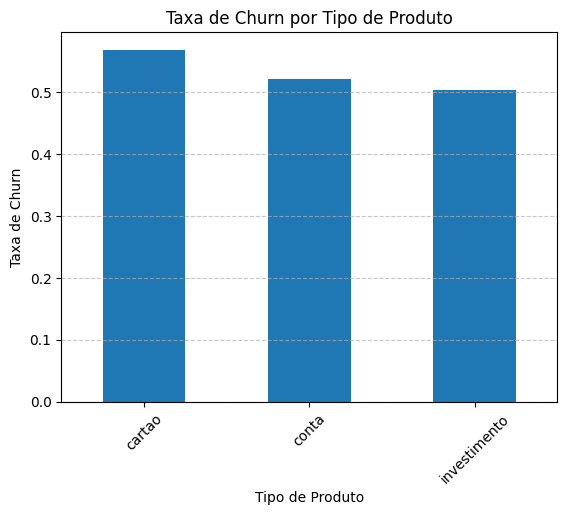

In [187]:
# Plotar o gráfico de barras
taxa_churn.plot(kind='bar')
plt.title('Taxa de Churn por Tipo de Produto')
plt.xlabel('Tipo de Produto')
plt.ylabel('Taxa de Churn')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Gerar regplot mostrando a relação entre tempo de relacionamento e probabilidade de churn

Total de clientes: 500
Clientes ativos no mês 12: 277
Taxa de churn baseada na atividade no mês 12: 44.6000


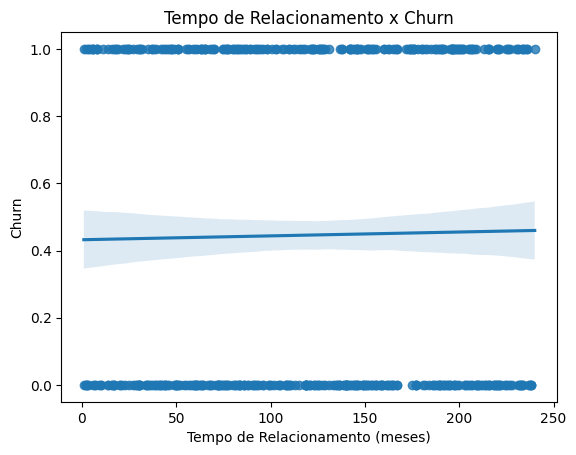

In [ ]:
# Identificar clientes ativos no mês 12
clientes_ativos_mes12 = df_transacoes[df_transacoes['mes'] == 12]['id_cliente'].unique()

# Número total de clientes
total_clientes = len(df_clientes)
 
# Número de clientes ativos no mês 12
num_ativos = len(clientes_ativos_mes12)

# Taxa de churn (clientes não ativos no mês 12 / total de clientes)
taxa_churn_mes12 = ((total_clientes - num_ativos) / total_clientes ) * 100

print(f"Total de clientes: {total_clientes}")
print(f"Clientes ativos no mês 12: {num_ativos}")
print(f"Taxa de churn baseada na atividade no mês 12: {taxa_churn_mes12:.4f}")

df_clientes['churn_mes'] = np.where(df_clientes['id_cliente'].isin(clientes_ativos_mes12), 0, 1)

sns.regplot(
    data=df_clientes,
    x='tempo_relacionamento_meses',
    y='churn_mes'
)

plt.title('Tempo de Relacionamento x Churn')
plt.xlabel('Tempo de Relacionamento (meses)')
plt.ylabel('Churn')

plt.show()

### Treinar um modelo de Regressão Logística com AUC -ROC >= 0,80 para prever churn

In [189]:
df_concatenado = pd.concat([df_clientes, df_transacoes, df_reclamacoes], axis=1, ignore_index=False)
df_concatenado.head()

,id_cliente,idade,tempo_relacionamento_meses,numero_produtos,segmento,tipo_produto,churn,churn_mes,id_cliente,mes,quantidade_transacoes,valor_total,id_cliente,motivo,resolvido
0,1.0,31.0,167.0,1.0,universitario,investimento,0.0,0.0,476,9,45,6685.86,25.0,tarifas,1.0
1,2.0,57.0,139.0,3.0,varejo,cartao,0.0,0.0,279,9,77,14.52,458.0,outros,1.0
2,3.0,19.0,233.0,2.0,varejo,cartao,1.0,1.0,402,9,94,1532.50,60.0,outros,1.0
3,4.0,33.0,174.0,5.0,universitario,cartao,0.0,1.0,414,10,18,7049.04,270.0,atendimento,1.0
4,5.0,56.0,142.0,1.0,varejo,investimento,0.0,1.0,423,11,80,15181.30,300.0,outros,0.0


In [190]:
x = df_concatenado[['id_cliente', 'tempo_relacionamento_meses', 'numero_produtos', 'mes', 'quantidade_transacoes', 'valor_total', 'resolvido']]
y = df_concatenado['churn']

In [191]:
x = x.dropna()
y = y.dropna()

In [192]:
display(x)
display(y)

,id_cliente,id_cliente,id_cliente,tempo_relacionamento_meses,numero_produtos,mes,quantidade_transacoes,valor_total,resolvido
0,1.0,476,25.0,167.0,1.0,9,45,6685.86,1.0
1,2.0,279,458.0,139.0,3.0,9,77,14.52,1.0
2,3.0,402,60.0,233.0,2.0,9,94,1532.50,1.0
3,4.0,414,270.0,174.0,5.0,10,18,7049.04,1.0
4,5.0,423,300.0,142.0,1.0,11,80,15181.30,0.0
...,...,...,...,...,...,...,...,...,...
295,296.0,455,423.0,65.0,1.0,10,82,2921.74,1.0
296,297.0,288,107.0,109.0,4.0,9,28,19803.54,1.0
297,298.0,241,387.0,87.0,3.0,5,33,4242.25,1.0
298,299.0,221,59.0,220.0,4.0,9,50,19712.82,1.0


0      0.0
1      0.0
2      1.0
3      0.0
4      0.0
      ... 
495    1.0
496    0.0
497    0.0
498    1.0
499    1.0
Name: churn, Length: 500, dtype: float64

In [193]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



ValueError: Found input variables with inconsistent numbers of samples: [300, 500]

In [ ]:
x_train

,tempo_relacionamento_meses
249,87.0
433,197.0
19,142.0
322,30.0
332,69.0
...,...
106,145.0
270,42.0
348,35.0
435,51.0


In [ ]:
modelo = LogisticRegression()
modelo.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_probs = modelo.predict_proba(x_test)[:, 1]

In [ ]:
# Calcular FPR, TPR e thresholds
auc = roc_auc_score(y_test, y_probs)

# Calcular a área sob a curva (AUC)
#valor_auc = auc(fpr, tpr)
print(f"O valor do AUC é: {auc:.4f}")

O valor do AUC é: 0.5598


# RPA

In [ ]:


# Criando a pasta de relatórios caso não exista 
if not os.path.exists('./relatorios_churn'):
    os.makedirs('./relatorios_churn')

# 1. Identificando os Top 20 clientes com maior probabilidade de churn 
df_concatenado['probabilidade_modelo'] = modelo.predict_proba(scaler.transform(X))[:, 1]
top_20_risco = df_concatenado.nlargest(20, 'probabilidade_modelo')

# 2. Criando colunas de "Ação Sugerida" e "Motivo" para o RPA 
top_20_risco['Ação Sugerida'] = "Oferecer isenção de tarifa e ligar para o cliente"
top_20_risco['Motivo Principal'] = top_20_risco['motivo'].fillna("Baixo Engajamento")

# 3. Selecionando apenas as colunas pedidas no PDF 
relatorio_final = top_20_risco[['id_cliente', 'probabilidade_modelo', 'Motivo Principal', 'Ação Sugerida']]

# 4. Salvando em Excel 
caminho_arquivo = './relatorios_churn/relatorio_diario_churn.xlsx'
relatorio_final.to_excel(caminho_arquivo, index=False)

print(f"RPA Concluído: Relatório salvo em {caminho_arquivo}")

NameError: name 'os' is not defined